# Peramalan kadar NO2 di daerah Sampang Madura

## Latar Belakang

Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO2), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO2 memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO2 juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

## 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Sampang.
Pengumpulan data dari sumber website https://dataspace.copernicus.eu/, buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

In [10]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection = connection.authenticate_oidc()

print("Login berhasil")
print(connection)

Authenticated using refresh token.
Login berhasil
<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>


Code diatas memerlukan titik koordinasi area yang akan diambil datanya. Berikut adalah koordinat daerah Sampang yang digunakan:

In [11]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.2460335, -7.1934948],
            [113.2521432, -7.1938433],
            [113.2489029, -7.2007571],
            [113.2443743, -7.199537],
            [113.2414463, -7.1948698],
            [113.2460335, -7.1934948],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2026-04-03", "2026-06-03"],
    spatial_extent={
        "west": 113.2414463,
        "south": -7.2007571,
        "east": 113.2521432,
        "north": -7.1934948
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Code diatas memerlukan titik koordinasi area yang akan diambil data 
-nya, untuk mengambil titik koordinasi kaian kunjungi webiste https://geojson.io/?map=14.13/-7.2/113.25#map=14.8/-7.04732/112.69463 . Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

![gambar no2 sampang](data/no2/geojson.png)

Jalankan batch job untuk mengambil data NO2 di daerah Sampang:

In [12]:
import os

os.makedirs("data", exist_ok=True)

# Hapus file lama jika ada agar tidak terjadi PermissionError
output_file = "data/NO2Sampang.nc"
if os.path.exists(output_file):
    try:
        os.remove(output_file)
        print(f"File lama '{output_file}' berhasil dihapus.")
    except PermissionError:
        # Jika file terkunci, gunakan nama file alternatif
        output_file = "data/NO2Sampang_new.nc"
        print(f"File lama terkunci, menyimpan ke '{output_file}'")

job = s5post.execute_batch(title="NO2 in Sampang", outputfile=output_file)
print("Download selesai!")

0:00:00 Job 'j-26060305180240e48e842077d1554d03': send 'start'
0:00:06 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:00:12 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:00:18 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:00:26 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:00:36 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:00:49 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:01:05 Job 'j-26060305180240e48e842077d1554d03': queued (progress 0%)
0:01:24 Job 'j-26060305180240e48e842077d1554d03': running (progress N/A)
0:01:48 Job 'j-26060305180240e48e842077d1554d03': running (progress N/A)
0:02:18 Job 'j-26060305180240e48e842077d1554d03': finished (progress 100%)
Download selesai!


Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://openeo.dataspace.copernicus.eu/?discover=0 Disitu terdapat nama dataset dan status pengambilan data.

![gambar openEo](data/no2/openeo.png)

## 2. Preprocessing Data

Setelah kita mengambil data, data bisa diunduh di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2. File akan berbentuk .nc. Kita cuman perlu kolom date dan NO2.

In [13]:
import netCDF4
import os

# Cari file .nc yang tersedia
if os.path.exists("data/NO2Sampang_new.nc"):
    file_path = "data/NO2Sampang_new.nc"
elif os.path.exists("data/NO2Sampang.nc"):
    file_path = "data/NO2Sampang.nc"
elif os.path.exists("NO2Sampang.nc"):
    file_path = "NO2Sampang.nc"
else:
    raise FileNotFoundError("File NO2Sampang.nc tidak ditemukan!")

print(f"Membaca file: {file_path}")
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

# Tampilkan struktur data NO2
print("\nBanyaknya data record NO2:", len(no2))
print("Panjang data perbaris:", len(no2[0]))
print("Panjang perdata:", len(no2[0][0]))
print("Contoh nilai:", no2[0][0][0])

# Tutup dataset agar file tidak terkunci
ds.close()

print("\nContoh data pertama:")
for i in range(min(10, len(no2))):
    print(no2[i])

Membaca file: data/NO2Sampang.nc
Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

Banyaknya data record NO2: 59
Panjang data perbaris: 1
Panjang perdata: 1
Contoh nilai: 2.2064343e-05

Contoh data pertama:
[[2.2064343284000643e-05]]
[[--]]
[[9.470276381762233e-06]]
[[--]]
[[--]]
[[--]]
[[--]]
[[--]]
[[--]]
[[1.2959280866198242e-05]]


### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

Dalam sehari, terdapat banyak data NO2, jadi kita rata-ratakan agar satu cell data hanya terdapat satu value. Namun terdapat masalah pada data NO2 seperti missing value. Sekarang kita akan mengatasi permasalahan missing value pada data NO2 menggunakan metode Interpolasi Linear.

In [14]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
no2_filled = no2_filled.filled(0)

for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').values

### b. Rata-ratakan Data dan ubah Datetime

Setelah mengatasi missing value, kita akan me-rata-rata-kan data NO2 agar satu record hanya berupa single value.

In [15]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Sampang_timeseries.csv", index=False)
print(df.head())
print(df.info())

         date       NO2
0  2026-04-03  0.000022
1  2026-04-04  0.000016
2  2026-04-05  0.000009
3  2026-04-06  0.000010
4  2026-04-08  0.000010
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    59 non-null     object 
 1   NO2     59 non-null     float32
dtypes: float32(1), object(1)
memory usage: 836.0+ bytes
None


### c. Pengecekan Missing Value data harian pada CSV

Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap.

In [16]:
df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 2
Daftar tanggal missing:
DatetimeIndex(['2026-04-07', '2026-04-23'], dtype='datetime64[ns]', freq=None)


Jika terdapat missing value harian, kita akan mengatasinya menggunakan Interpolasi Linear:

In [17]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(method='time')
df['NO2'] = df['NO2'].bfill().ffill()

df = df.reset_index()
df.columns = ['date', 'NO2']

df.to_csv("no2_timeseries_interpolated.csv", index=False)

missing_check = full_range.difference(pd.to_datetime(df['date']))
print(f"Jumlah hari missing setelah interpolasi: {len(missing_check)}")
print(df.head())
print(df.info())

Jumlah hari missing setelah interpolasi: 0
        date       NO2
0 2026-04-03  0.000022
1 2026-04-04  0.000016
2 2026-04-05  0.000009
3 2026-04-06  0.000010
4 2026-04-07  0.000010
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    61 non-null     datetime64[ns]
 1   NO2     61 non-null     float32       
dtypes: datetime64[ns](1), float32(1)
memory usage: 860.0 bytes
None


### d. Deteksi Outlier IQR

Selanjutnya kita akan mendeteksi Outlier menggunakan metode IQR.

In [18]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]
print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 0
Empty DataFrame
Columns: [date, NO2]
Index: []


Visualisasi outlier:

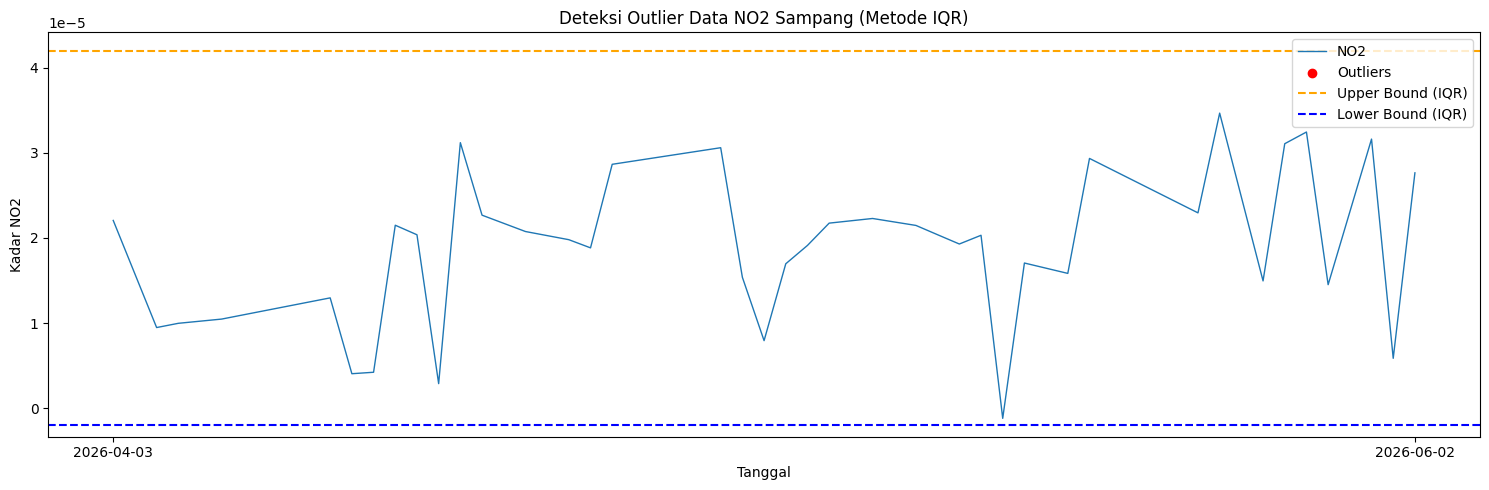

In [19]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], 
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 Sampang (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Menghapus data outlier dan mengisi kembali menggunakan Interpolasi Linear:

Jumlah nilai yang dinyatakan sebagai outlier: 0
Jumlah missing setelah interpolasi: 0


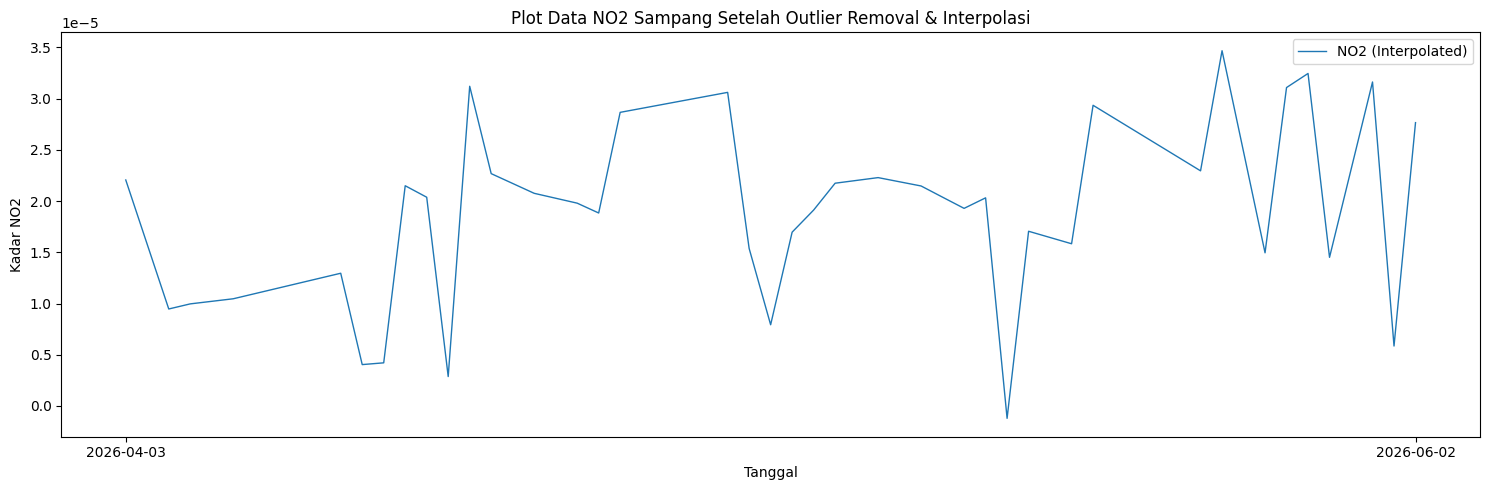

In [20]:
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))
print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)

plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.title("Plot Data NO2 Sampang Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modeling menggunakan KNN Regression

Dengan data Time Series kadar NO2 harian di daerah Sampang, kita akan memprediksi kadar NO2 **1 hari ke depan (besok)** berdasarkan **2 hari sebelumnya**.

### a. Normalisasi Data

Karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan Min-Max Scaler.

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])
print(df[['date', 'NO2_filled', 'NO2_scaled']].head())
print(df.info())

        date  NO2_filled  NO2_scaled
0 2026-04-03    0.000022    0.648388
1 2026-04-04    0.000016    0.472930
2 2026-04-05    0.000009    0.297471
3 2026-04-06    0.000010    0.311359
4 2026-04-07    0.000010    0.318303
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         61 non-null     datetime64[ns]
 1   NO2          61 non-null     float32       
 2   NO2_cleaned  61 non-null     float32       
 3   NO2_filled   61 non-null     float32       
 4   NO2_scaled   61 non-null     float32       
dtypes: datetime64[ns](1), float32(4)
memory usage: 1.6 KB
None


### b. Uji Korelasi Data

Kita ubah data menjadi supervised lalu uji korelasi terhadap label (t). Fitur-fiturnya merupakan hari-hari sebelumnya.

In [22]:
def create_supervised(data, n_lag=2):
    df_supervised = pd.DataFrame()
    
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    
    df_supervised['NO2(t)'] = data
    df_supervised.dropna(inplace=True)
    
    return df_supervised

# Uji korelasi dengan 10 hari sebelumnya
supervised_corr = create_supervised(df['NO2_scaled'], n_lag=10)

lag_cols = supervised_corr.drop(columns="NO2(t)").columns
correlations = supervised_corr[lag_cols].corrwith(supervised_corr['NO2(t)'])

print("Nilai korelasi tiap lag terhadap t:")
print(correlations)

Nilai korelasi tiap lag terhadap t:
NO2(t-10)    0.082329
NO2(t-9)     0.217912
NO2(t-8)     0.069272
NO2(t-7)     0.117582
NO2(t-6)     0.126729
NO2(t-5)    -0.035935
NO2(t-4)     0.083051
NO2(t-3)     0.390311
NO2(t-2)     0.154784
NO2(t-1)     0.234719
dtype: float64


### c. Mengubah Data menjadi Supervised

Kita menggunakan **2 hari sebelumnya** (t-2, t-1) sebagai fitur untuk memprediksi hari H (t).

In [23]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=2)
print(supervised_df)
print(supervised_df.shape)

    NO2(t-2)  NO2(t-1)    NO2(t)
2   0.648388  0.472930  0.297471
3   0.472930  0.297471  0.311359
4   0.297471  0.311359  0.318303
5   0.311359  0.318303  0.325247
6   0.318303  0.325247  0.339135
7   0.325247  0.339135  0.353024
8   0.339135  0.353024  0.366912
9   0.353024  0.366912  0.380800
10  0.366912  0.380800  0.394688
11  0.380800  0.394688  0.146205
12  0.394688  0.146205  0.150999
13  0.146205  0.150999  0.632701
14  0.150999  0.632701  0.601449
15  0.632701  0.601449  0.113697
16  0.601449  0.113697  0.903267
17  0.113697  0.903267  0.665653
18  0.903267  0.665653  0.638881
19  0.665653  0.638881  0.612109
20  0.638881  0.612109  0.598723
21  0.612109  0.598723  0.585337
22  0.598723  0.585337  0.558565
23  0.585337  0.558565  0.832340
24  0.558565  0.832340  0.843208
25  0.832340  0.843208  0.854076
26  0.843208  0.854076  0.864944
27  0.854076  0.864944  0.875812
28  0.864944  0.875812  0.886679
29  0.875812  0.886679  0.462087
30  0.886679  0.462087  0.254568
31  0.4620

### d. Modeling dan Evaluation

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} - Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred

# Train model dengan 2 hari sebelumnya
knn_model, y_test, y_pred = train_knn(supervised_df, "KNN - 2 Hari Sebelumnya")


=== KNN - 2 Hari Sebelumnya ===
Train Size: 47 - Test Size: 12
RMSE: 0.346084
R2 Score: -1.2815
MAPE: 63.3301%


### e. Plotting

Visualisasi grafik antara label aktual dan prediksi.

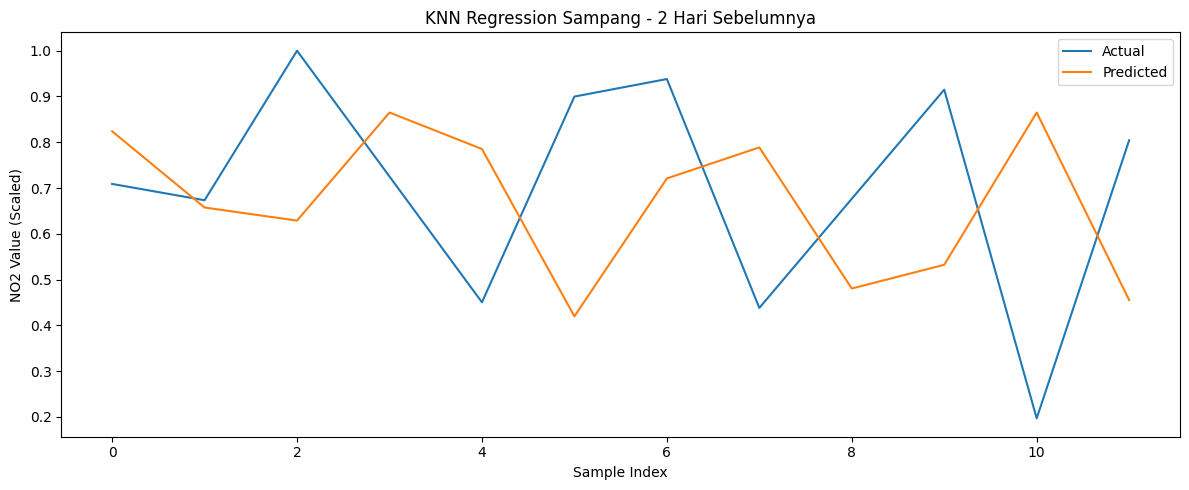

In [25]:
plt.figure(figsize=(12,5))
plt.plot(np.arange(len(y_test)), y_test, label="Actual", linewidth=1.5)
plt.plot(np.arange(len(y_pred)), y_pred, label="Predicted", linewidth=1.5)
plt.title("KNN Regression Sampang - 2 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value (Scaled)")
plt.legend()
plt.tight_layout()
plt.show()

### f. Prediksi NO2 Hari Besok

Menggunakan model KNN yang sudah di-train, kita prediksi kadar NO2 untuk **hari besok** berdasarkan 2 hari terakhir data yang tersedia.

In [26]:
# Ambil 2 hari terakhir dari data scaled
last_2_days = df['NO2_scaled'].values[-2:]
last_2_dates = df['date'].values[-2:]

print("Data 2 hari terakhir yang digunakan untuk prediksi:")
for i, (d, v) in enumerate(zip(last_2_dates, last_2_days)):
    print(f"  t-{2-i}: {pd.Timestamp(d).strftime('%Y-%m-%d')} -> NO2 scaled: {v:.6f}")

# Prediksi
input_data = last_2_days.reshape(1, -1)
pred_scaled = knn_model.predict(input_data)[0]

# Inverse transform ke nilai asli
pred_original = scaler.inverse_transform([[pred_scaled]])[0][0]

# Tanggal besok
last_date = pd.Timestamp(df['date'].values[-1])
tomorrow = last_date + pd.Timedelta(days=1)

print(f"\n========================================")
print(f"  PREDIKSI NO2 SAMPANG")
print(f"  Tanggal: {tomorrow.strftime('%Y-%m-%d')}")
print(f"  Kadar NO2 (scaled): {pred_scaled:.6f}")
print(f"  Kadar NO2 (asli)  : {pred_original:.10f}")
print(f"========================================")

Data 2 hari terakhir yang digunakan untuk prediksi:
  t-2: 2026-06-01 -> NO2 scaled: 0.196691
  t-1: 2026-06-02 -> NO2 scaled: 0.804360

  PREDIKSI NO2 SAMPANG
  Tanggal: 2026-06-03
  Kadar NO2 (scaled): 0.628286
  Kadar NO2 (asli)  : 0.0000213429
